**15. STUDENT EXAM PASS PREDICTION SYSTEM (LOGISTIC REGRESSION)**

**OBJECTIVE 1: DATA COLLECTION**

**CELL 1: MOUNT GOOGLE DRIVE**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**CELL 2: IMPORT REQUIRED LIBRARIES**

In [2]:
import pandas as pd
import numpy as np
# VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
# PREPROCESSING
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
# MODEL BUILDING
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
# MODEL EVALUATION
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
import warnings
warnings.filterwarnings('ignore')

**CELL 3: LOAD DATASET**

In [3]:
path = "/content/drive/MyDrive/Colab Notebooks/student_performance_dataset.csv"
df = pd.read_csv(path)
print("DATASET LOADED SUCCESSFULLY")

DATASET LOADED SUCCESSFULLY


**CELL 4: DISPLAY DATASET**

In [4]:
df.head()

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass


**CELL 5: DATASET INFORMATION**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  708 non-null    object 
 1   Gender                      708 non-null    object 
 2   Study_Hours_per_Week        708 non-null    int64  
 3   Attendance_Rate             708 non-null    float64
 4   Past_Exam_Scores            708 non-null    int64  
 5   Parental_Education_Level    708 non-null    object 
 6   Internet_Access_at_Home     708 non-null    object 
 7   Extracurricular_Activities  708 non-null    object 
 8   Final_Exam_Score            708 non-null    int64  
 9   Pass_Fail                   708 non-null    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 55.4+ KB


**CELL 6: DATASET SHAPE**

In [6]:
print("NUMBER OF ROWS :", df.shape[0])
print("NUMBER OF COLUMNS :", df.shape[1])

NUMBER OF ROWS : 708
NUMBER OF COLUMNS : 10


**OBJECTIVE 2: DATA CLEANING & PREPROCESSING**

**CELL 7: CHECK MISSING VALUES**

In [7]:
df.isnull().sum()

,0
Student_ID,0
Gender,0
Study_Hours_per_Week,0
Attendance_Rate,0
Past_Exam_Scores,0
Parental_Education_Level,0
Internet_Access_at_Home,0
Extracurricular_Activities,0
Final_Exam_Score,0
Pass_Fail,0


**CELL 8: REMOVE DUPLICATES**

In [8]:
print("BEFORE REMOVING DUPLICATES :", df.shape)
df = df.drop_duplicates()
print("AFTER REMOVING DUPLICATES :", df.shape)

BEFORE REMOVING DUPLICATES : (708, 10)
AFTER REMOVING DUPLICATES : (500, 10)


**CELL 9: CHECK DATA TYPES**

In [9]:
df.dtypes

,0
Student_ID,object
Gender,object
Study_Hours_per_Week,int64
Attendance_Rate,float64
Past_Exam_Scores,int64
Parental_Education_Level,object
Internet_Access_at_Home,object
Extracurricular_Activities,object
Final_Exam_Score,int64
Pass_Fail,object


**CELL 10: ENCODE CATEGORICAL VARIABLES**

In [10]:
le = LabelEncoder()
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
print("CATEGORICAL VARIABLES ENCODED SUCCESSFULLY")

CATEGORICAL VARIABLES ENCODED SUCCESSFULLY


**CELL 11: REMOVE STUDENT_ID**

In [11]:
if 'Student_ID' in df.columns:
    df.drop('Student_ID', axis=1, inplace=True)
print("STUDENT_ID COLUMN REMOVED")

STUDENT_ID COLUMN REMOVED


**CELL 12: DISPLAY CLEANED DATASET**

In [12]:
df.head()

,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,1,31,68.267841,86,1,1,1,63,1
1,1,16,78.222927,73,3,0,0,50,0
2,0,21,87.525096,74,3,1,0,55,0
3,0,27,92.076483,99,0,0,0,65,1
4,0,37,98.655517,63,2,0,1,70,1


**OBJECTIVE 3: DESCRIPTIVE STATISTICS**

**CELL 13: STATISTICAL SUMMARY**

In [13]:
df.describe()

,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.488000,25.184000,75.830689,75.218000,1.464000,0.474000,0.464000,56.378000,0.292000
std,0.500357,8.804384,13.969186,14.442841,1.114984,0.499824,0.499202,6.266551,0.455138
min,0.000000,10.000000,50.116970,50.000000,0.000000,0.000000,0.000000,50.000000,0.000000
25%,0.000000,18.000000,64.959340,62.000000,0.000000,0.000000,0.000000,50.000000,0.000000
50%,0.000000,26.000000,76.752661,75.500000,1.000000,0.000000,0.000000,55.000000,0.000000
75%,1.000000,33.000000,87.548861,88.000000,2.000000,1.000000,1.000000,61.000000,1.000000
max,1.000000,39.000000,99.967675,100.000000,3.000000,1.000000,1.000000,77.000000,1.000000


**CELL 14: AVERAGE STUDY HOURS**

In [14]:
avg_study = df['Study_Hours_per_Week'].mean()
print("AVERAGE STUDY HOURS :", round(avg_study, 2))

AVERAGE STUDY HOURS : 25.18


**CELL 15: AVERAGE ATTENDANCE RATE**

In [15]:
avg_attendance = df['Attendance_Rate'].mean()
print("AVERAGE ATTENDANCE RATE :", round(avg_attendance, 2))

AVERAGE ATTENDANCE RATE : 75.83


**CELL 16: AVERAGE PAST EXAM SCORES**

In [16]:
avg_past = df['Past_Exam_Scores'].mean()
print("AVERAGE PAST EXAM SCORE :", round(avg_past, 2))

AVERAGE PAST EXAM SCORE : 75.22


**CELL 17: AVERAGE FINAL EXAM SCORE**

In [17]:
avg_final = df['Final_Exam_Score'].mean()
print("AVERAGE FINAL EXAM SCORE :", round(avg_final, 2))

AVERAGE FINAL EXAM SCORE : 56.38


**CELL 18: PASS VS FAIL COUNT**

In [18]:
df['Pass_Fail'].value_counts()

,count
Pass_Fail,
0,354
1,146


**OBJECTIVE 4: STUDENT PERFORMANCE ANALYSIS**

**CELL 19: PASS VS FAIL ANALYSIS**

In [19]:
df.groupby('Pass_Fail').mean()

,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score
Pass_Fail,,,,,,,,
0,0.502825,23.500000,72.641772,71.587571,1.457627,0.488701,0.437853,52.980226
1,0.452055,29.267123,83.562720,84.020548,1.479452,0.438356,0.527397,64.616438


**CELL 20: INTERNET ACCESS IMPACT**

In [20]:
df.groupby('Internet_Access_at_Home')['Final_Exam_Score'].mean()

,Final_Exam_Score
Internet_Access_at_Home,
0,56.505703
1,56.236287


**CELL 21: EXTRACURRICULAR ACTIVITIES IMPACT**

In [21]:
df.groupby('Extracurricular_Activities')['Final_Exam_Score'].mean()

,Final_Exam_Score
Extracurricular_Activities,
0,56.119403
1,56.676724


**OBJECTIVE 5: GROUP-BASED ANALYSIS**

**CELL 22: STUDY HOURS VS PASS/FAIL**

In [22]:
study_analysis = df.groupby('Pass_Fail')['Study_Hours_per_Week'].mean()
study_analysis

,Study_Hours_per_Week
Pass_Fail,
0,23.500000
1,29.267123


**CELL 23: ATTENDANCE VS PASS/FAIL**

In [23]:
attendance_analysis = df.groupby('Pass_Fail')['Attendance_Rate'].mean()
attendance_analysis

,Attendance_Rate
Pass_Fail,
0,72.641772
1,83.562720


**CELL 24: GENDER VS PASS RATE**

In [24]:
gender_analysis = df.groupby('Gender')['Pass_Fail'].mean()
gender_analysis

,Pass_Fail
Gender,
0,0.312500
1,0.270492


**CELL 25: PARENTAL EDUCATION ANALYSIS**

In [25]:
parent_analysis = df.groupby('Parental_Education_Level')['Final_Exam_Score'].mean()
parent_analysis

,Final_Exam_Score
Parental_Education_Level,
0,56.220472
1,56.229630
2,57.000000
3,56.107438


**OBJECTIVE 6: RELATIONSHIP ANALYSIS**

**CELL 26: CORRELATION MATRIX**

In [26]:
corr = df.corr()
corr

,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
Gender,1.000000,-0.082291,0.010712,0.036829,-0.036697,0.002757,0.014313,-0.018044,-0.046182
Study_Hours_per_Week,-0.082291,1.000000,-0.039701,-0.013381,0.049262,0.051182,-0.046821,0.374708,0.298128
Attendance_Rate,0.010712,-0.039701,1.000000,-0.022741,0.010365,0.030660,0.007578,0.435714,0.355821
Past_Exam_Scores,0.036829,-0.013381,-0.022741,1.000000,-0.029067,-0.029611,0.019297,0.474257,0.391801
Parental_Education_Level,-0.036697,0.049262,0.010365,-0.029067,1.000000,0.014499,-0.034737,0.007831,0.008909
Internet_Access_at_Home,0.002757,0.051182,0.030660,-0.029611,0.014499,1.000000,0.048447,-0.021489,-0.045843
Extracurricular_Activities,0.014313,-0.046821,0.007578,0.019297,-0.034737,0.048447,1.000000,0.044397,0.081640
Final_Exam_Score,-0.018044,0.374708,0.435714,0.474257,0.007831,-0.021489,0.044397,1.000000,0.845135
Pass_Fail,-0.046182,0.298128,0.355821,0.391801,0.008909,-0.045843,0.081640,0.845135,1.000000


**CELL 27: STUDY HOURS VS FINAL EXAM SCORE**

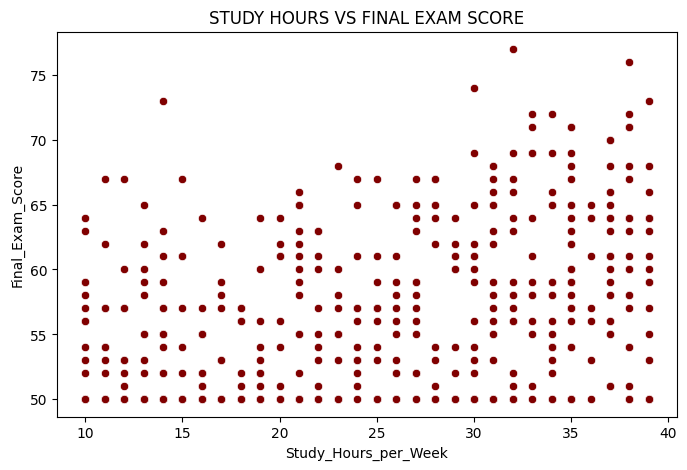

In [27]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['Study_Hours_per_Week'],
    y=df['Final_Exam_Score'],
    color='maroon'
)
plt.title("STUDY HOURS VS FINAL EXAM SCORE")
plt.show()

**CELL 28: ATTENDANCE VS FINAL EXAM SCORE**

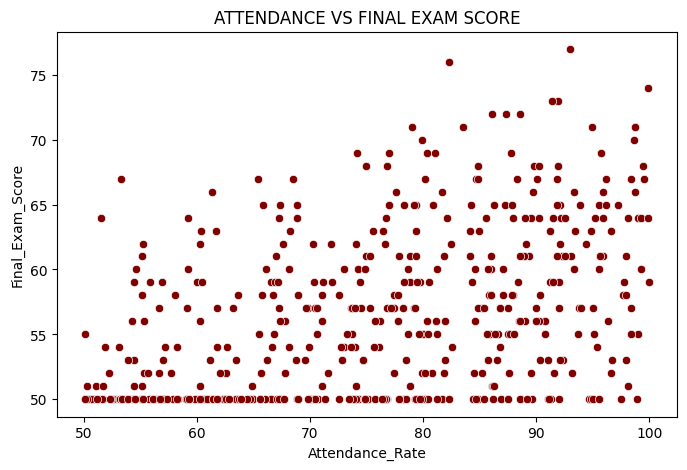

In [28]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['Attendance_Rate'],
    y=df['Final_Exam_Score'],
    color='maroon'
)
plt.title("ATTENDANCE VS FINAL EXAM SCORE")
plt.show()

**OBJECTIVE 7: DATA VISUALIZATION**

**CELL 29: PASS VS FAIL DISTRIBUTION**

In [29]:
fig = px.bar(
    df['Pass_Fail'].value_counts(),
    title='PASS VS FAIL DISTRIBUTION',
    color_discrete_sequence=['maroon']
)
fig.show()

**CELL 30: GENDER DISTRIBUTION**

In [30]:
fig = px.pie(
    df,
    names='Gender',
    title='GENDER DISTRIBUTION',
    color_discrete_sequence=['maroon']
)

fig.show()

**CELL 31: STUDY HOURS DISTRIBUTION**

In [31]:
fig = px.histogram(
    df,
    x='Study_Hours_per_Week',
    title='STUDY HOURS DISTRIBUTION',
    color_discrete_sequence=['maroon']
)

fig.show()

**CELL 32: ATTENDANCE RATE DISTRIBUTION**

In [32]:
fig = px.histogram(
    df,
    x='Attendance_Rate',
    title='ATTENDANCE RATE DISTRIBUTION',
    color_discrete_sequence=['maroon']
)
fig.show()

**CELL 33: FINAL EXAM SCORE DISTRIBUTION**

In [33]:
fig = px.histogram(
    df,
    x='Final_Exam_Score',
    title='FINAL EXAM SCORE DISTRIBUTION',
    color_discrete_sequence=['maroon']
)
fig.show()

**CELL 34: BOX PLOT FOR FINAL EXAM SCORE**

In [34]:

fig = px.box(
    df,
    y='Final_Exam_Score',
    title='BOX PLOT - FINAL EXAM SCORE',
    color_discrete_sequence=['maroon']
)
fig.show()

**CELL 35: CORRELATION HEATMAP**

In [35]:
fig = px.imshow(
    df.corr(),
    text_auto=True,
    title='CORRELATION HEATMAP',
    color_continuous_scale='Reds'
)

fig.show()

**OBJECTIVE 8: RISK ANALYSIS**

**CELL 36: CREATE RISK CATEGORIES**

In [36]:
conditions = [
    (
        (df['Attendance_Rate'] < 60) &
        (df['Study_Hours_per_Week'] < 10) &
        (df['Past_Exam_Scores'] < 50)
    ),
    (
        (df['Attendance_Rate'] >= 60) &
        (df['Attendance_Rate'] < 80)
    ),
    (
        (df['Attendance_Rate'] >= 80)
    )
]
risk_labels = ['HIGH RISK', 'MEDIUM RISK', 'LOW RISK']
df['Risk_Level'] = np.select(conditions, risk_labels, default='NOT CLASSIFIED')
df[['Risk_Level']].head()

,Risk_Level
0,MEDIUM RISK
1,MEDIUM RISK
2,LOW RISK
3,LOW RISK
4,LOW RISK


**CELL 37: RISK LEVEL DISTRIBUTION**

In [37]:
fig = px.pie(
    df,
    names='Risk_Level',
    title='RISK LEVEL DISTRIBUTION',
    color_discrete_sequence=['maroon']
)
fig.show()

**OBJECTIVE 9: PREDICTIVE MODELING (LOGISTIC REGRESSION)**

**CELL 38: DEFINE FEATURES AND TARGET**

In [38]:
X = df.drop(['Pass_Fail', 'Risk_Level'], axis=1)
y = df['Pass_Fail']

**CELL 39: FEATURE SCALING**

In [39]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**CELL 40: TRAIN TEST SPLIT**

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)
print("TRAINING DATA SHAPE :", X_train.shape)
print("TESTING DATA SHAPE :", X_test.shape)

TRAINING DATA SHAPE : (400, 8)
TESTING DATA SHAPE : (100, 8)


**CELL 41: TRAIN LOGISTIC REGRESSION MODEL**

In [41]:
model = LogisticRegression()
model.fit(X_train, y_train)
print("MODEL TRAINING COMPLETED")

MODEL TRAINING COMPLETED


**CELL 42: PREDICTIONS**

In [42]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]
print(y_pred[:10])

[0 1 0 0 1 0 0 1 0 0]


**OBJECTIVE 10: MODEL EVALUATION**

**CELL 43: ACCURACY SCORE**

In [43]:
accuracy = accuracy_score(y_test, y_pred)
print("ACCURACY :", round(accuracy*100,2), "%")

ACCURACY : 98.0 %


**CELL 44: PRECISION SCORE**

In [44]:
precision = precision_score(y_test, y_pred)
print("PRECISION :", round(precision,2))

PRECISION : 1.0


**CELL 45: RECALL SCORE**

In [45]:
recall = recall_score(y_test, y_pred)
print("RECALL :", round(recall,2))

RECALL : 0.92


**CELL 46: F1 SCORE**

In [46]:
f1 = f1_score(y_test, y_pred)
print("F1 SCORE :", round(f1,2))

F1 SCORE : 0.96


**CELL 47: CONFUSION MATRIX**

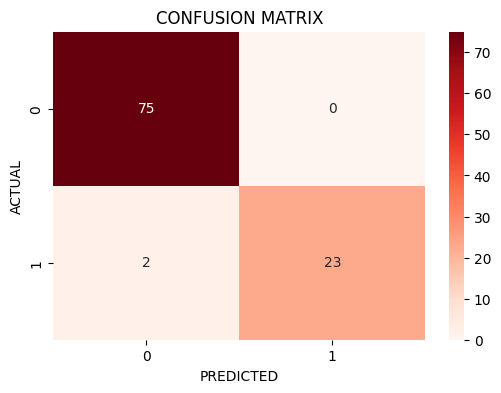

In [47]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds'
)
plt.title("CONFUSION MATRIX")
plt.xlabel("PREDICTED")
plt.ylabel("ACTUAL")
plt.show()

**CELL 48: CLASSIFICATION REPORT**

In [48]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        75
           1       1.00      0.92      0.96        25

    accuracy                           0.98       100
   macro avg       0.99      0.96      0.97       100
weighted avg       0.98      0.98      0.98       100



**CELL 49: ROC-AUC SCORE**

In [49]:
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC SCORE :", round(roc_auc,2))

ROC-AUC SCORE : 1.0


**CELL 50: ROC CURVE**

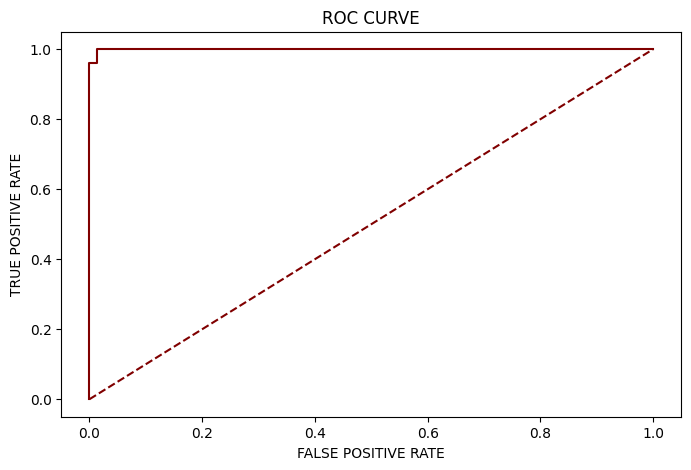

In [50]:
fpr, tpr, threshold = roc_curve(y_test, y_prob)
plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, color='maroon')
plt.plot([0,1], [0,1], color='maroon', linestyle='--')
plt.title("ROC CURVE")
plt.xlabel("FALSE POSITIVE RATE")
plt.ylabel("TRUE POSITIVE RATE")
plt.show()

**OBJECTIVE 11: DASHBOARD CREATION**

**CELL 51: STUDENT RISK DASHBOARD**

In [51]:
fig = px.bar(
    df,
    x='Risk_Level',
    color='Pass_Fail',
    title='STUDENT RISK DASHBOARD',
    color_discrete_sequence=px.colors.sequential.Reds_r
)
fig.show()

**CELL 52: ATTENDANCE ANALYSIS DASHBOARD**

In [52]:
fig = px.scatter(
    df,
    x='Attendance_Rate',
    y='Final_Exam_Score',
    color='Pass_Fail',
    title='ATTENDANCE ANALYSIS DASHBOARD',
    color_discrete_sequence=px.colors.sequential.Reds_r
)

fig.show()

**CELL 53: STUDY HOURS DASHBOARD**

In [53]:
fig = px.scatter(
    df,
    x='Study_Hours_per_Week',
    y='Final_Exam_Score',
    color='Risk_Level',
    title='STUDY HOURS DASHBOARD',
    color_discrete_sequence=px.colors.sequential.Reds_r
)
fig.show()

**CELL 54: INTERACTIVE CORRELATION HEATMAP**

In [54]:
numeric_df = df.select_dtypes(include=np.number)
fig = px.imshow(
    numeric_df.corr(),
    text_auto=True,
    title='INTERACTIVE CORRELATION HEATMAP',
    color_continuous_scale='Reds_r'
)

fig.show()

**OBJECTIVE 12: INSIGHTS & CONCLUSION**

**CELL 55: FINAL INSIGHTS**

In [55]:
print("""
1. STUDENTS WITH HIGHER ATTENDANCE PERFORM BETTER IN EXAMS.
2. STUDY HOURS POSITIVELY IMPACT FINAL EXAM SCORES.
3. PAST EXAM SCORES STRONGLY INFLUENCE PASS/FAIL PREDICTION.
4. INTERNET ACCESS IMPROVES STUDENT PERFORMANCE.
5. HIGH-RISK STUDENTS REQUIRE EARLY ACADEMIC SUPPORT.
6. LOGISTIC REGRESSION SUCCESSFULLY PREDICTS PASS/FAIL STATUS.
7. ATTENDANCE AND STUDY HABITS ARE MAJOR SUCCESS FACTORS.
8. VISUALIZATIONS AND DASHBOARDS SUPPORT DATA-DRIVEN DECISIONS.
""")


1. STUDENTS WITH HIGHER ATTENDANCE PERFORM BETTER IN EXAMS.
2. STUDY HOURS POSITIVELY IMPACT FINAL EXAM SCORES.
3. PAST EXAM SCORES STRONGLY INFLUENCE PASS/FAIL PREDICTION.
4. INTERNET ACCESS IMPROVES STUDENT PERFORMANCE.
5. HIGH-RISK STUDENTS REQUIRE EARLY ACADEMIC SUPPORT.
6. LOGISTIC REGRESSION SUCCESSFULLY PREDICTS PASS/FAIL STATUS.
7. ATTENDANCE AND STUDY HABITS ARE MAJOR SUCCESS FACTORS.
8. VISUALIZATIONS AND DASHBOARDS SUPPORT DATA-DRIVEN DECISIONS.

